
Model comparison
         Model                 Parameters    MSE     AIC     BIC
Noncompetitive  [54.5793, 2.0577, 1.9149] 0.1706 -9.9157 -9.3240
   Competitive  [50.6046, 1.8509, 1.3225] 0.2333 -7.0991 -6.5074
 Uncompetitive [106.0035, 4.8392, 0.2889] 0.3477 -3.5073 -2.9157
  No inhibitor          [37.9059, 1.9761] 6.9225 21.4130 21.8074

Best model according to BIC: Noncompetitive
Parameters: [54.5793  2.0577  1.9149]


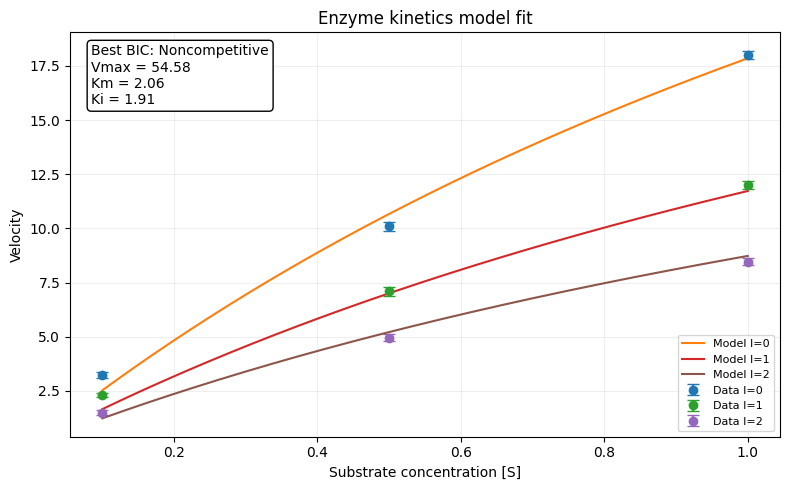

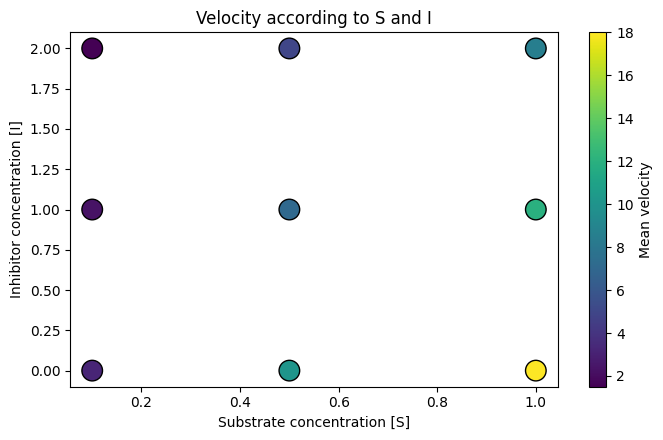

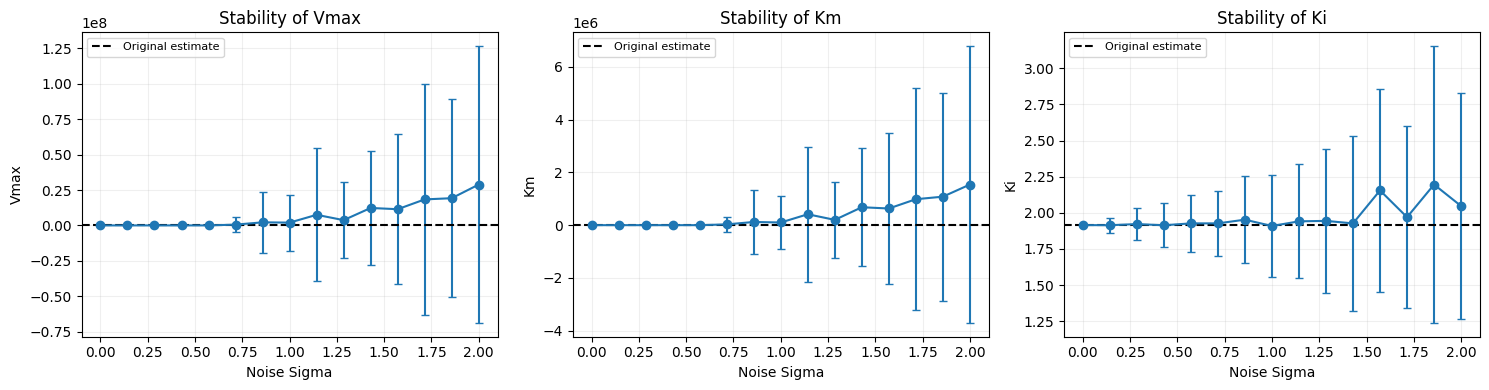

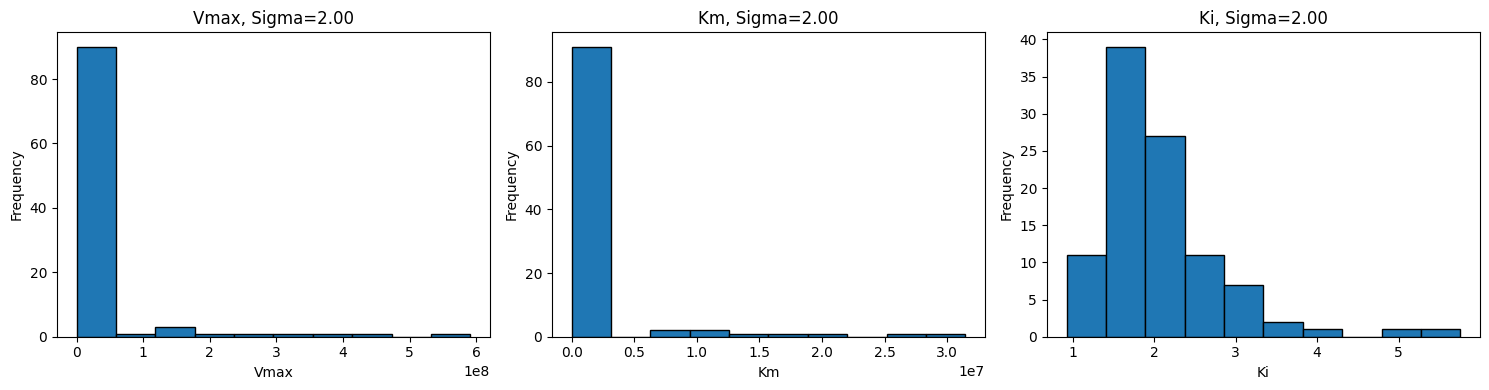


Analysis completed
Files were saved in the results folder


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

np.set_printoptions(suppress=True)


# ---------------------------- #
# ------ User settings ------- #
# ---------------------------- #

FILE_NAME = "data/Datos_experimento.csv"
SIGMA_MAX = 2.0
N_MONTE_CARLO = 100
RANDOM_SEED = 42


# ---------------------------- #
# ---------- Models ---------- #
# ---------------------------- #

def model_no_inhibitor(S, Vmax, Km):
    return Vmax * S / (S + Km)


def model_competitive(x, Vmax, Km, Ki):
    S, I = x
    return Vmax * S / (Km * (1 + I / Ki) + S)


def model_noncompetitive(x, Vmax, Km, Ki):
    S, I = x
    return (Vmax / (1 + I / Ki)) * (S / (Km + S))


def model_uncompetitive(x, Vmax, Km, Ki):
    S, I = x
    return Vmax * S / (Km + S * (1 + I / Ki))


Models = [
    ("No inhibitor", model_no_inhibitor),
    ("Competitive", model_competitive),
    ("Noncompetitive", model_noncompetitive),
    ("Uncompetitive", model_uncompetitive)
]


# ---------------------------- #
# -------- CSV files --------- #
# ---------------------------- #

def create_example_file():

    if os.path.exists(FILE_NAME):
        return

    lines = [
        "S,rep1,rep2,rep3,I",
        "0.1,3.2,3.4,3.1,0",
        "0.5,10.1,9.9,10.3,0",
        "1.0,18.2,17.8,18.0,0",
        "0.1,2.2,2.4,2.3,1",
        "0.5,7.1,6.9,7.3,1",
        "1.0,12.2,11.8,12.0,1",
        "0.1,1.5,1.4,1.6,2",
        "0.5,5.0,4.8,5.1,2",
        "1.0,8.5,8.3,8.6,2"
    ]

    with open(FILE_NAME, "w", encoding="utf-8") as file:
        file.write("\n".join(lines))


def read_experimental_file():
    Data = pd.read_csv(FILE_NAME)

    required_columns = ["S", "rep1", "rep2", "rep3"]

    for column in required_columns:
        if column not in Data.columns:
            raise ValueError(f"The column {column} is missing from the CSV file")

    S = Data["S"].values.astype(float)
    Replicates = Data[["rep1", "rep2", "rep3"]].values.astype(float)

    if "I" in Data.columns:
        I = Data["I"].fillna(0).values.astype(float)
    else:
        print("Column I was not found. No inhibitor will be assumed.")
        I = np.zeros_like(S)

    return Data, S, Replicates, I


# -------------------------------- #
# ---- Precision measurements ---- #
# -------------------------------- #

def calculate_precision(Replicates):


    Means = np.nanmean(Replicates, axis=1)

    # ddof=1 gives the sample standard deviation.
    Standard_deviations = np.nanstd(Replicates, axis=1, ddof=1)

    return Means, Standard_deviations


# ---------------------------- #
# ------ Model fitting ------- #
# ---------------------------- #

def fit_models(S, I, v):
    Results = []
    inhibitor_present = len(np.unique(I)) > 1

    for name, model in Models:
        try:
            if name == "No inhibitor":
                params, matrix = curve_fit(
                    model,
                    S,
                    v,
                    bounds=([1e-8, 1e-8], [np.inf, np.inf]),
                    p0=[20, 0.5],
                    maxfev=50000
                )

                predictions = model(S, *params)

            elif inhibitor_present:
                params, matrix = curve_fit(
                    model,
                    (S, I),
                    v,
                    bounds=(
                        [1e-8, 1e-8, 1e-8],
                        [np.inf, np.inf, np.inf]
                    ),
                    p0=[20, 0.5, 1],
                    maxfev=50000
                )

                predictions = model((S, I), *params)

            else:
                continue

            residuals = v - predictions
            mse = np.mean(residuals ** 2)
            rss = np.sum(residuals ** 2)

            n = len(v)
            k = len(params)
            rss = max(rss, np.finfo(float).eps)

            aic = n * np.log(rss / n) + 2 * k
            bic = n * np.log(rss / n) + k * np.log(n)

            Results.append({
                "Model": name,
                "Parameters": params,
                "MSE": mse,
                "AIC": aic,
                "BIC": bic,
                "Matrix": matrix
            })

        except Exception as error:
            print(f"Error in model {name}: {error}")

    if len(Results) == 0:
        raise RuntimeError("No model could be fitted")

    Best_result = min(Results, key=lambda result: result["BIC"])

    return Results, Best_result


def print_results(Results, Best_result):
    rows = []

    for result in Results:
        rows.append({
            "Model": result["Model"],
            "Parameters": np.round(result["Parameters"], 4),
            "MSE": round(result["MSE"], 4),
            "AIC": round(result["AIC"], 4),
            "BIC": round(result["BIC"], 4)
        })

    Table = pd.DataFrame(rows).sort_values("BIC")

    print("\nModel comparison")
    print(Table.to_string(index=False))

    print("\nBest model according to BIC:", Best_result["Model"])
    print("Parameters:", np.round(Best_result["Parameters"], 4))

    os.makedirs("results", exist_ok=True)
    Table.to_csv("results/model_comparison.csv", index=False)


# ---------------------------- #
# ------ Main plot ----------- #
# ---------------------------- #

def plot_best_model(S, I, v, Standard_deviations, Best_result):
    best_name = Best_result["Model"]
    best_params = Best_result["Parameters"]
    best_model = [model for name, model in Models if name == best_name][0]

    S_smooth = np.linspace(min(S), max(S), 200)

    plt.figure(figsize=(8, 5))

    for inhibitor in np.unique(I):
        mask = I == inhibitor

        plt.errorbar(
            S[mask],
            v[mask],
            yerr=Standard_deviations[mask],
            fmt="o",
            capsize=4,
            label=f"Data I={inhibitor:g}"
        )

        if best_name != "No inhibitor":
            I_smooth = np.full_like(S_smooth, inhibitor)
            curve = best_model((S_smooth, I_smooth), *best_params)

            plt.plot(
                S_smooth,
                curve,
                label=f"Model I={inhibitor:g}"
            )

    if best_name == "No inhibitor":
        curve = best_model(S_smooth, *best_params)
        plt.plot(S_smooth, curve, color="black", label="Best model")

    text = f"Vmax = {best_params[0]:.2f}\nKm = {best_params[1]:.2f}"

    if len(best_params) == 3:
        text += f"\nKi = {best_params[2]:.2f}"

    plt.text(
        0.03,
        0.97,
        f"Best BIC: {best_name}\n{text}",
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white")
    )

    plt.xlabel("Substrate concentration [S]")
    plt.ylabel("Velocity")
    plt.title("Enzyme kinetics model fit")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig("results/model_fit.png", dpi=300)
    plt.show()


def plot_substrate_inhibitor_map(S, I, v):
    if len(np.unique(I)) <= 1:
        return

    plt.figure(figsize=(7, 4.5))

    plot = plt.scatter(
        S,
        I,
        c=v,
        s=220,
        cmap="viridis",
        edgecolor="black"
    )

    plt.colorbar(plot, label="Mean velocity")
    plt.xlabel("Substrate concentration [S]")
    plt.ylabel("Inhibitor concentration [I]")
    plt.title("Velocity according to S and I")
    plt.tight_layout()
    plt.savefig("results/substrate_inhibitor_map.png", dpi=300)
    plt.show()


# ---------------------------- #
# ------- Monte Carlo -------- #
# ---------------------------- #

def add_noise(Velocity, Sigma, random_generator):
    noise = random_generator.normal(0, Sigma, size=Velocity.shape)
    return Velocity + noise


def monte_carlo(S, I, v, Best_result):
    best_name = Best_result["Model"]
    best_params = Best_result["Parameters"]
    best_model = [model for name, model in Models if name == best_name][0]
    random_generator = np.random.default_rng(RANDOM_SEED)

    sigma_values = np.linspace(0, SIGMA_MAX, 15)
    Records = []

    for sigma in sigma_values:
        for iteration in range(N_MONTE_CARLO):
            noisy_v = add_noise(v, sigma, random_generator)

            try:
                if best_name == "No inhibitor":
                    params, matrix = curve_fit(
                        best_model,
                        S,
                        noisy_v,
                        bounds=([1e-8, 1e-8], [np.inf, np.inf]),
                        p0=best_params,
                        maxfev=50000
                    )

                else:
                    params, matrix = curve_fit(
                        best_model,
                        (S, I),
                        noisy_v,
                        bounds=(
                            [1e-8, 1e-8, 1e-8],
                            [np.inf, np.inf, np.inf]
                        ),
                        p0=best_params,
                        maxfev=50000
                    )

                record = {
                    "Sigma": sigma,
                    "Iteration": iteration,
                    "Vmax": params[0],
                    "Km": params[1]
                }

                if len(params) == 3:
                    record["Ki"] = params[2]

                Records.append(record)

            except Exception:
                continue

    Monte_carlo_data = pd.DataFrame(Records)

    if len(Monte_carlo_data) == 0:
        raise RuntimeError("All Monte Carlo adjustments failed")

    Monte_carlo_data.to_csv(
        "results/monte_carlo_results.csv",
        index=False
    )

    return Monte_carlo_data


def plot_monte_carlo(Monte_carlo_data, Best_result):
    parameters = ["Vmax", "Km"]

    if "Ki" in Monte_carlo_data.columns:
        parameters.append("Ki")

    plt.figure(figsize=(5 * len(parameters), 4))

    for index, parameter in enumerate(parameters):
        Means = Monte_carlo_data.groupby("Sigma")[parameter].mean()
        Deviations = Monte_carlo_data.groupby("Sigma")[parameter].std()

        plt.subplot(1, len(parameters), index + 1)

        plt.errorbar(
            Means.index,
            Means.values,
            yerr=Deviations.fillna(0).values,
            fmt="o-",
            capsize=3
        )

        plt.axhline(
            Best_result["Parameters"][index],
            color="black",
            linestyle="--",
            label="Original estimate"
        )

        plt.xlabel("Noise Sigma")
        plt.ylabel(parameter)
        plt.title(f"Stability of {parameter}")
        plt.grid(alpha=0.2)
        plt.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("results/monte_carlo_stability.png", dpi=300)
    plt.show()

    maximum_sigma = Monte_carlo_data["Sigma"].max()

    Maximum_noise = Monte_carlo_data[
        np.isclose(Monte_carlo_data["Sigma"], maximum_sigma)
    ]

    plt.figure(figsize=(5 * len(parameters), 4))

    for index, parameter in enumerate(parameters):
        plt.subplot(1, len(parameters), index + 1)
        plt.hist(Maximum_noise[parameter], bins=10, edgecolor="black")
        plt.xlabel(parameter)
        plt.ylabel("Frequency")
        plt.title(f"{parameter}, Sigma={maximum_sigma:.2f}")

    plt.tight_layout()
    plt.savefig("results/monte_carlo_histograms.png", dpi=300)
    plt.show()


# ---------------------------- #
# ------- Main workflow ------ #
# ---------------------------- #

def main():
    os.makedirs("data", exist_ok=True)
    os.makedirs("results", exist_ok=True)

    create_example_file()

    Data, S, Replicates, I = read_experimental_file()

    v, Standard_deviations = calculate_precision(Replicates)

    Results, Best_result = fit_models(S, I, v)

    print_results(Results, Best_result)

    plot_best_model(
        S,
        I,
        v,
        Standard_deviations,
        Best_result
    )

    plot_substrate_inhibitor_map(S, I, v)

    Monte_carlo_data = monte_carlo(
        S,
        I,
        v,
        Best_result
    )

    plot_monte_carlo(
        Monte_carlo_data,
        Best_result
    )

    print("\nAnalysis completed")
    print("Files were saved in the results folder")


main()
